In [68]:
## Load my files ##
import sys
sys.path.append('..')
from utils import get_sequence

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torch import from_numpy as tnsr
from scipy.stats import bernoulli
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist as dist
from sklearn.metrics.pairwise import cosine_similarity
from scipy.signal import find_peaks
from sklearn.manifold import MDS, TSNE 
from matplotlib import cm
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

In [271]:
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1, token_size=7):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True, nonlinearity='relu')
        self.fc1 = nn.Linear(hidden_size, token_size)
        
    def forward(self, x, hw=None, short_term_memory=None):
        if hw is None:
            out, hw = self.rnn(x)
        else:   
            out, hw = self.rnn(x, hw)
            
        out = self.fc1(out[:,-1,:])
        return out, hw

In [272]:
def compute_geodesic(hidden1, hidden2):

    total_layers = len(hidden1)
    w = 0

    for ii in range(total_layers):
        w_ = np.array(dist( hidden1[ii], hidden2[ii], 'cosine'))
        w += w_
           
    return w[0][0]/total_layers

In [273]:
class Dataset_converter(Dataset):
    def __init__(self, data, token_size, working_memory=1, short_term_memory=8):
        
        one_hot_encoded = np.zeros((len(data), token_size), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((((len(data)-working_memory-short_term_memory)), short_term_memory, token_size*working_memory))
        self.y = np.zeros((((len(data)-working_memory-short_term_memory)), token_size))

        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                for kk in range(working_memory):
                    self.X[ii,jj,kk*token_size:(kk+1)*token_size] = \
                    one_hot_encoded[ii+jj+kk,:]
                    
            self.y[ii] = \
                one_hot_encoded[ii+jj+kk+1,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [274]:
total_samples = 60000
working_memory = 1
short_term_memory = 7
n_community = 2
n_members = 3
node = 20
layer = 1
lr = 4e-4

token_size = n_community*n_members+1
input_size = token_size*working_memory

train_data = get_sequence(total_samples, n_community, n_members)#, train_percent=(1/3.0))
# train_data = ''

# for ii in range(len(train_data_)):
#      if train_data_[ii] == 'G':
#           continue
#      else:
#           train_data = train_data + train_data_[ii]


model = RNN(input_size, node, num_layers=layer, token_size=token_size)

data_set = Dataset_converter(train_data, token_size, working_memory, short_term_memory)
train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
correct_train = np.zeros(1000,dtype=float)
train_acc = []
for (X_train, y_train) in train_loader:
    optimizer.zero_grad()

    if total == 0:
        predicted_y, hidden = model(X_train, short_term_memory=short_term_memory)
    else:
        predicted_y, hidden = model(X_train, hw=memory, short_term_memory=short_term_memory)

    
    loss = criterion(predicted_y, y_train)
    loss.backward(retain_graph=True)
    optimizer.step()

    with torch.no_grad():
        memory = hidden.clone()
        true_y = y_train.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=1)

        total += 1
        if true_y == estimated_y:
            correct_train[total%1000] = 1
        else:
            correct_train[total%1000] = 0


        train_acc.append(
            np.sum(correct_train)/total if total<1000 else np.sum(correct_train)/1000
        )
        
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, train accuracy: {train_acc[-1]:.4f}')


Iter : 1001, loss: 1.9639, train accuracy: 0.2360
Iter : 2001, loss: 2.5914, train accuracy: 0.3320
Iter : 3001, loss: 1.3580, train accuracy: 0.5550
Iter : 4001, loss: 1.0458, train accuracy: 0.6180
Iter : 5001, loss: 0.9444, train accuracy: 0.6390
Iter : 6001, loss: 0.1222, train accuracy: 0.6930
Iter : 7001, loss: 0.0965, train accuracy: 0.6750
Iter : 8001, loss: 0.0337, train accuracy: 0.6900
Iter : 9001, loss: 0.0473, train accuracy: 0.6860
Iter : 10001, loss: 0.0356, train accuracy: 0.6890
Iter : 11001, loss: 0.0526, train accuracy: 0.7060
Iter : 12001, loss: 0.0505, train accuracy: 0.7000
Iter : 13001, loss: 0.1252, train accuracy: 0.7130
Iter : 14001, loss: 0.0175, train accuracy: 0.7290
Iter : 15001, loss: 0.0118, train accuracy: 0.7390
Iter : 16001, loss: 0.0032, train accuracy: 0.7690
Iter : 17001, loss: 0.0046, train accuracy: 0.7340
Iter : 18001, loss: 0.0025, train accuracy: 0.7920
Iter : 19001, loss: 0.0497, train accuracy: 0.8130
Iter : 20001, loss: 0.0037, train accura

In [275]:
compressor_sample = 2000

data_compressor, direction = get_sequence(compressor_sample, n_community, n_members, train=True, return_direction=True)#, train_percent=(1/3.0))

# data_compressor = ''

# for ii in range(len(data_compressor_)):
#      if data_compressor_[ii] == 'G':
#           continue
#      else:
#           data_compressor = data_compressor + data_compressor_[ii]

data_set_compressor =  Dataset_converter(data_compressor, token_size, working_memory, short_term_memory)
compressor_loader = DataLoader(data_set_compressor, batch_size=1, shuffle=False) 
hidden_states = []

ii = 0
dis = [0]
# community = ''
com = []
token = []
rule = []

d = 0
with torch.no_grad():
    for X, _ in compressor_loader:
        if X[0][-1].argmax()<3:
            com.append('Com 1')
            if direction[d]:
                rule.append('Com1 clockwise')
            else:
                rule.append('Com1 xclockwise')

        elif X[0][-1].argmax()<6:
            com.append('Com 2')
            if direction[d]:
                rule.append('Com2 clockwise')
            else:
                rule.append('Com2 xclockwise')
        else:
            com.append('G')
            d += 1
            rule.append('G')
        
        token.append(chr(X[0][-1].argmax()+ord('A')))
        
        if ii==0:
            id, hw = model(X)
            id_current = hw
            hidden_states.append(hw[0][0])
            # community = tokens[torch.argmax(X[0])]
        else:
            id, hw = model(X, hw=hw)
            id_current = hw
            hidden_states.append(hw[0][0])
            
            if ii>=1:
                dis.append(compute_geodesic(prev_id, id_current))
                # print(dis)
                # if dis[-1] >0.407:
                #     # print(dis, tokens[torch.argmax(X[0])])
                #     community += tokens[torch.argmax(X[0])]
                    
            
        prev_id = id_current
        ii += 1

In [276]:
dis_array = np.array(dis)
# threshold = np.quantile(dis_array, .8)
# peaks = find_peaks(dis_array, .7)[0]
peaks = [-100] 
threshold = 0.2
prev_dis = 1

for ii, dis in enumerate(dis_array):
    if prev_dis - dis >= threshold and peaks[-1]!=ii-2:
        peaks.append(ii-1)
    
    prev_dis = dis 

peaks.pop(0)
mask = np.zeros(dis_array.shape, dtype=int)
mask[peaks] = 1
# mask = ((dis_array>threshold)*1)

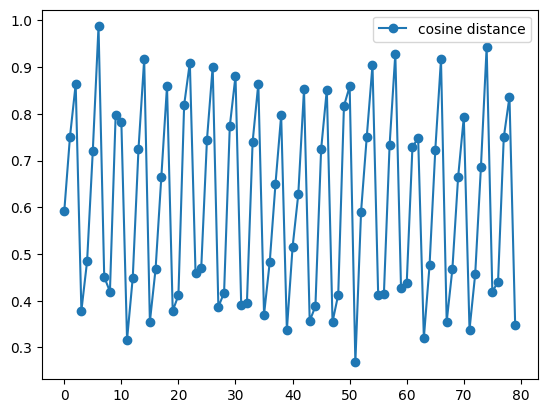

In [277]:
span = 80
plt.plot(dis_array[-span:], '-o', label='cosine distance')
# plt.plot(mask[-span:], c='k', label = 'mask')
plt.legend()

In [278]:
D = np.zeros((len(hidden_states), len(hidden_states)), dtype=float)

for ii in range(len(hidden_states)):
    for jj in range(len(hidden_states)):
        D[ii,jj] = dist([hidden_states[ii]], [hidden_states[jj]], 'cosine')[0][0]

# hidden_states = np.array(hidden_states)
embedding = MDS(n_components=4, dissimilarity='precomputed', random_state=101)#TSNE(n_components=2, perplexity=30, random_state=42)#
X_transformed = embedding.fit_transform(D)
# X_transformed = embedding.fit_transform(hidden_states)

In [279]:
data = pd.DataFrame()

for ii in range(4):
    data['component'+str(ii+1)] = X_transformed[:,ii]

data['community'] = com
data['token'] = token
data['rule'] = rule
# sns.set_context('talk')

# for ii in range(len(X_transformed)):
#     plt.plot(X_transformed[ii,0], X_transformed[ii,1], c=clr[com[ii]-1], marker='o')

# plt.xlabel('Component 1')
# plt.ylabel('Component 2')

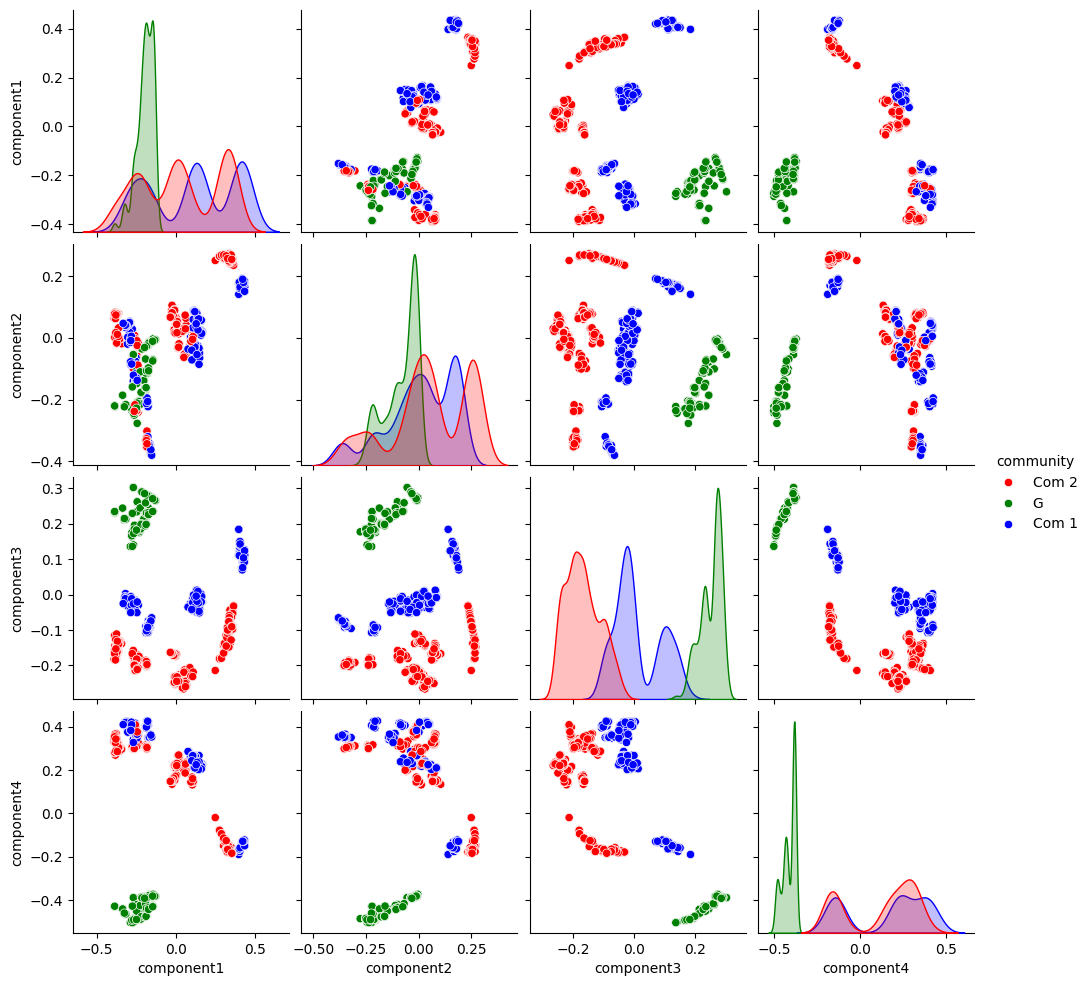

In [280]:
sns.pairplot(data, hue="community", palette=['r','g','b'])

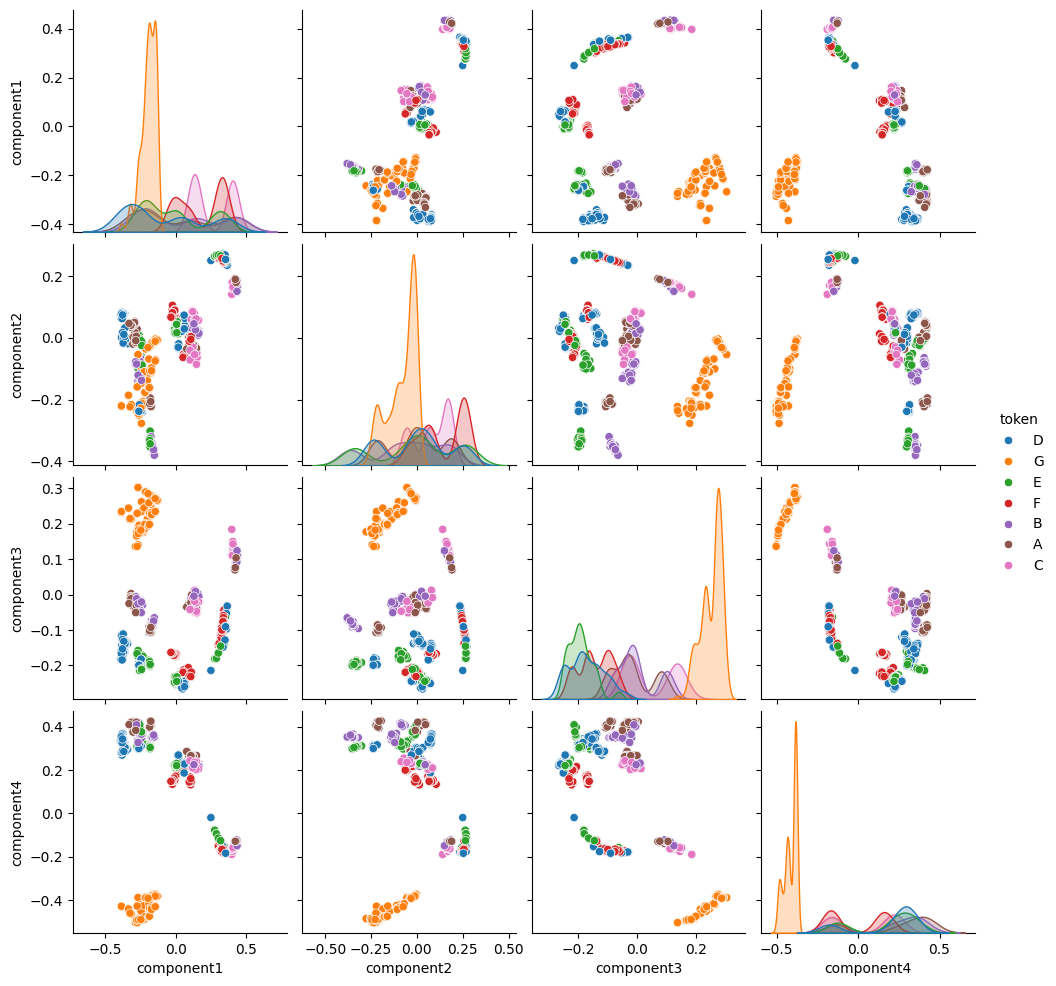

In [281]:
sns.pairplot(data, hue="token")

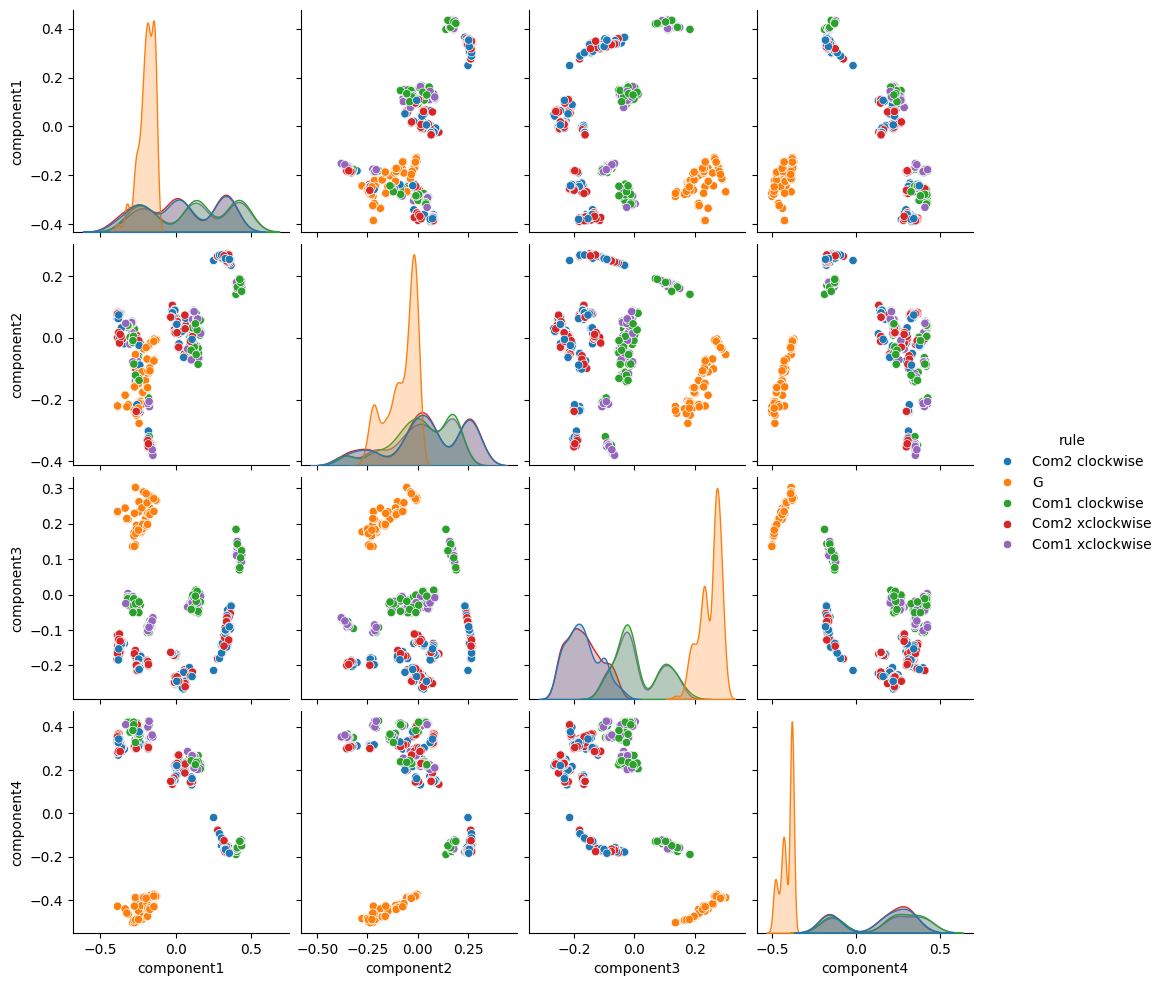

In [282]:
sns.pairplot(data, hue="rule")

In [170]:
n_components = [2,3,4,5]
stresses = []

for n_component in tqdm(n_components):
    embedding = MDS(n_components=n_component, dissimilarity='precomputed', random_state=101)
    X_transformed = embedding.fit_transform(D)
    stresses.append(embedding.stress_)


100%|██████████| 4/4 [01:06<00:00, 16.50s/it]


Text(0, 0.5, 'Stress')

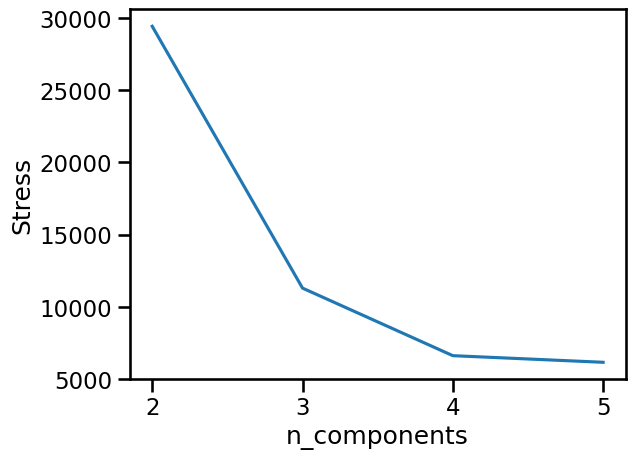

In [172]:
sns.set_context('talk')

plt.plot(n_components, stresses)

plt.xticks(n_components)
plt.xlabel('n_components')
plt.ylabel('Stress')

In [10]:
D = np.zeros((len(hidden_states), len(hidden_states)), dtype=float)

for ii in range(len(hidden_states)):
    for jj in range(len(hidden_states)):
        D[ii,jj] = dist([hidden_states[ii]], [hidden_states[jj]], 'cosine')[0][0]


In [15]:
n_components = [2,3,4,5,6,7,8,9,10]
stresses = []

for n_component in tqdm(n_components):
    embedding = TSNE(n_components=n_component, random_state=101, method='exact', n_jobs=-1)
    X_transformed = embedding.fit_transform(np.array(hidden_states))
    stresses.append(embedding.kl_divergence_)


100%|██████████| 9/9 [14:12<00:00, 94.71s/it] 


Text(0, 0.5, 'KL div')

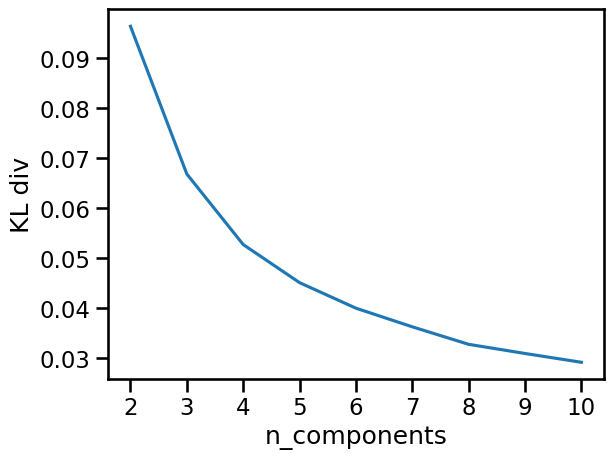

In [17]:
sns.set_context('talk')

plt.plot(n_components, stresses)

plt.xticks(n_components)
plt.xlabel('n_components')
plt.ylabel('KL div')

In [87]:
len(hidden_states[0])

10

In [146]:
h = np.array(hidden_states)

In [152]:
hidden_states_normalized = normalize(X_transformed, norm='l2')

In [153]:
# Apply K-Means clustering with cosine distance approximation
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(hidden_states_normalized)
centroids = kmeans.cluster_centers_

In [154]:
centroids

array([[ 2.4249804e-01,  3.2656312e-02,  2.9611498e-02,  2.2959769e-02,
         1.0161191e-01,  1.3248508e-01,  1.8402338e-03,  8.5045323e-02,
         7.0336461e-03,  8.4934270e-01],
       [ 2.6449263e-03,  1.1920929e-07,  6.7794478e-01, -4.4703484e-08,
         3.3527613e-08, -7.4505806e-08,  1.2105218e-01,  6.5753561e-01,
         1.9557089e-02,  5.0517157e-02],
       [ 1.4824300e-01,  4.5413131e-01,  1.4344254e-01,  2.3673779e-01,
         6.9594897e-02,  2.5177103e-01,  1.7756455e-01,  1.7177352e-01,
         3.8089842e-01,  3.2554790e-02]], dtype=float32)

In [155]:
labels[:30]

array([1, 0, 2, 2, 1, 0, 2, 2, 1, 0, 2, 2, 1, 0, 2, 2, 1, 0, 2, 2, 1, 0,
       2, 2, 1, 0, 2, 2, 1, 0], dtype=int32)

In [156]:
com[:30]

['Com 2',
 'G',
 'Com 2',
 'Com 2',
 'Com 2',
 'G',
 'Com 1',
 'Com 1',
 'Com 1',
 'G',
 'Com 2',
 'Com 2',
 'Com 2',
 'G',
 'Com 2',
 'Com 2',
 'Com 2',
 'G',
 'Com 2',
 'Com 2',
 'Com 2',
 'G',
 'Com 2',
 'Com 2',
 'Com 2',
 'G',
 'Com 2',
 'Com 2',
 'Com 2',
 'G']

In [67]:
data_compressor[6:]

'DGDEFGBACGEFDGEFDGDFEGEDFGEDFGEDFGEDFGBACGABCGDFEGBCAGABCGACBGACBGBACGDFEGBCAGDEFGEFDGACBGBCAGEDFGDEFGEDFGDFEGACBGDEFGBCAGDEFGBCAGDEFGEFDGBACGDEFGEFDGBACGABCGEDFGBCAGEFDGEFDGEDFGDFEGDFEGBACGEFDGBCAGEFDGDEFGEDFGDFEGACBGEFDGABCGBCAGDFEGEFDGBACGDEFGBCAGEFDGABCGBCAGACBGACBGACBGDFEGEFDGACBGABCGBACGDFEGDEFGACBGEFDGABCGBCAGDFEGABCGDEFGDEFGEDFGEDFGEDFGDFEGACBGEFDGEFDGACBGBCAGEDFGABCGBCAGEDFGDEFGBACGDEFGBCAGBCAGDFEGABCGABCGACBGEDFGEFDGACBGDEFGBCAGBCAGACBGACBGACBGEDFGABCGEFDGABCGDEFGEFDGDFEGDFEGDFEGBACGEFDGDEFGDFEGDFEGBACGDEFGDEFGBACGABCGEDFGABCGABCGBACGBACGDFEGDEFGBACGBCAGEDFGABCGDEFGDEFGDFEGDFEGBACGABCGACBGDFEGABCGDEFGEFDGEDFGBACGEFDGBCAGABCGDFEGBCAGEFDGEFDGBACGBCAGEDFGBCAGEFDGABCGDEFGABCGEFDGBCAGEFDGBCAGABCGACBGEDFGABCGEFDGBCAGEFDGBCAGBCAGACBGACBGACBGDFEGBCAGABCGDFEGABCGABCGBACGEDFGBCAGBCAGEDFGABCGEFDGABCGABCGEDFGEFDGBACGBCAGBACGDFEGDEFGBACGABCGACBGBACGBACGEDFGABCGDEFGBCAGBCAGACBGDFEGDEFGEDFGBACGABCGEDFGDEFGEDFGDFEGBACGBCAGBACGEDFGDEFGACBGDEFGBCAGBCAGEDFGBCAGDEFGDEFGDFEGDFEGACBGABCGBACGEDFGD

In [193]:
id

tensor([[-3.9455,  5.4366, 10.8286, -6.8191, -3.3826, -2.8432, -3.8946]])

In [237]:
import networkx as nx
import numpy as np
import torch
from sklearn.metrics.pairwise import cosine_similarity
import community as community_louvain  # pip install python-louvain

# Simulated hidden states (batch_size=300, hidden_dim=64)
hidden_states = np.array(hidden_states)

# Compute cosine similarity matrix
similarity_matrix = cosine_similarity(hidden_states)

# Build graph (only keep strong connections)
G = nx.Graph()
for i in range(similarity_matrix.shape[0]):
    for j in range(i + 1, similarity_matrix.shape[1]):
        if similarity_matrix[i, j] > 0.6:  # Set threshold for similarity
            G.add_edge(i, j, weight=similarity_matrix[i, j])

# Apply Louvain community detection
partition = community_louvain.best_partition(G)

print("Detected communities:", set(partition.values()))


Detected communities: {0, 1, 2}


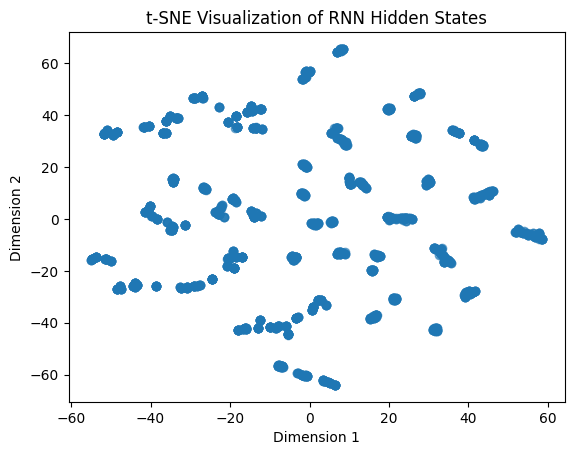

In [239]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Reduce hidden states to 2D using t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
hidden_states_2d = tsne.fit_transform(hidden_states)

# Scatter plot
plt.scatter(hidden_states_2d[:, 0], hidden_states_2d[:, 1], alpha=0.6)
plt.title("t-SNE Visualization of RNN Hidden States")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()
